In [279]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json

In [280]:
SAMPLE_DIR = Path("samples/v3_1000/res_20250627_n100")

queries_labeled_df = pd.read_csv(SAMPLE_DIR / "_queries_labeled.csv")
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
classified_urls_df = pd.read_csv(SAMPLE_DIR / "__classified_urls.csv")
unclassified_urls_df = pd.read_csv(SAMPLE_DIR / "__unclassified_urls.csv")

In [281]:
print(queries_labeled_df.columns)
print(responses_df.columns)
print(classified_urls_df.columns)
print(unclassified_urls_df.columns)

Index(['query_id', 'query_text', 'triggered_ai_overview'], dtype='object')
Index(['query_id', 'references', 'organic_results'], dtype='object')
Index(['url', 'ai_class', 'confidence'], dtype='object')
Index(['url', 'category'], dtype='object')


In [282]:
print("Number of queries:", len(queries_labeled_df))
print("Number of AI Overviews triggered:", (queries_labeled_df["triggered_ai_overview"] == 'y').sum())
print("")
print("Number of total documents:", len(classified_urls_df) + len(unclassified_urls_df))
print("Number of classified documents:", len(classified_urls_df))
print("Number of unclassified documents:", len(unclassified_urls_df))

Number of queries: 1000
Number of AI Overviews triggered: 409

Number of total documents: 35879
Number of classified documents: 23991
Number of unclassified documents: 11888


In [283]:
def plot_dist_pie(df, col, title=None):
    counts = df[col].value_counts(dropna=False)
    labels = [str(x) for x in counts.index]
    plt.figure(figsize=(4, 4))
    plt.pie(
        counts,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p/100.*sum(counts)))})',
        startangle=140
    )
    plt.title(title or f"{col} distribution")
    plt.tight_layout()
    plt.show()

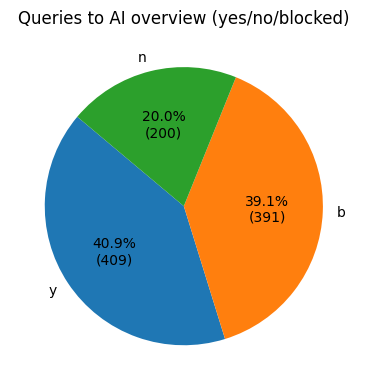

In [284]:
plot_dist_pie(queries_labeled_df, 'triggered_ai_overview', 'Queries to AI overview (yes/no/blocked)')

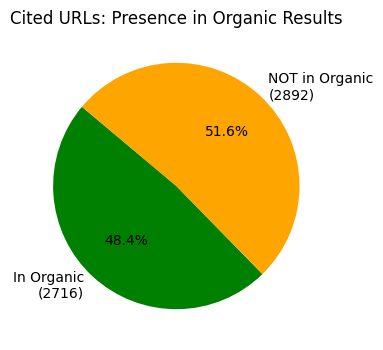

In [285]:
in_organic = 0
not_in_organic = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    for url in refs:
        if url in organic:
            in_organic += 1
        else:
            not_in_organic += 1

total = in_organic + not_in_organic
values = [in_organic, not_in_organic]
labels = [
    f"In Organic\n({in_organic})",
    f"NOT in Organic\n({not_in_organic})"
]

plt.figure(figsize=(4, 4))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=["green", "orange"],
    startangle=140
)
plt.title("Cited URLs: Presence in Organic Results")
plt.show()

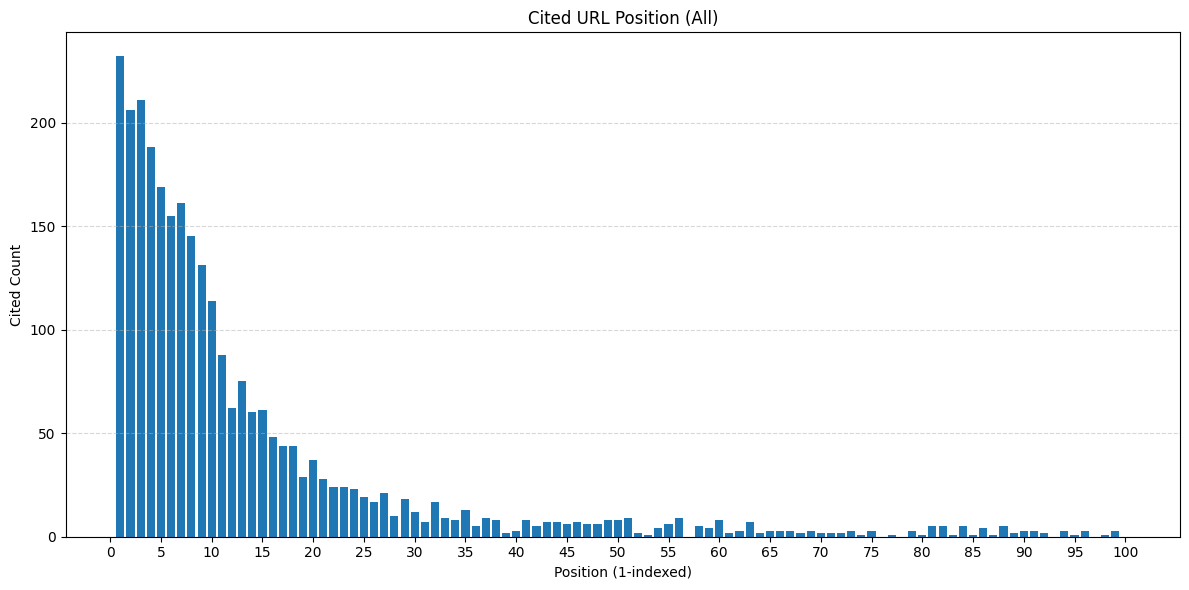

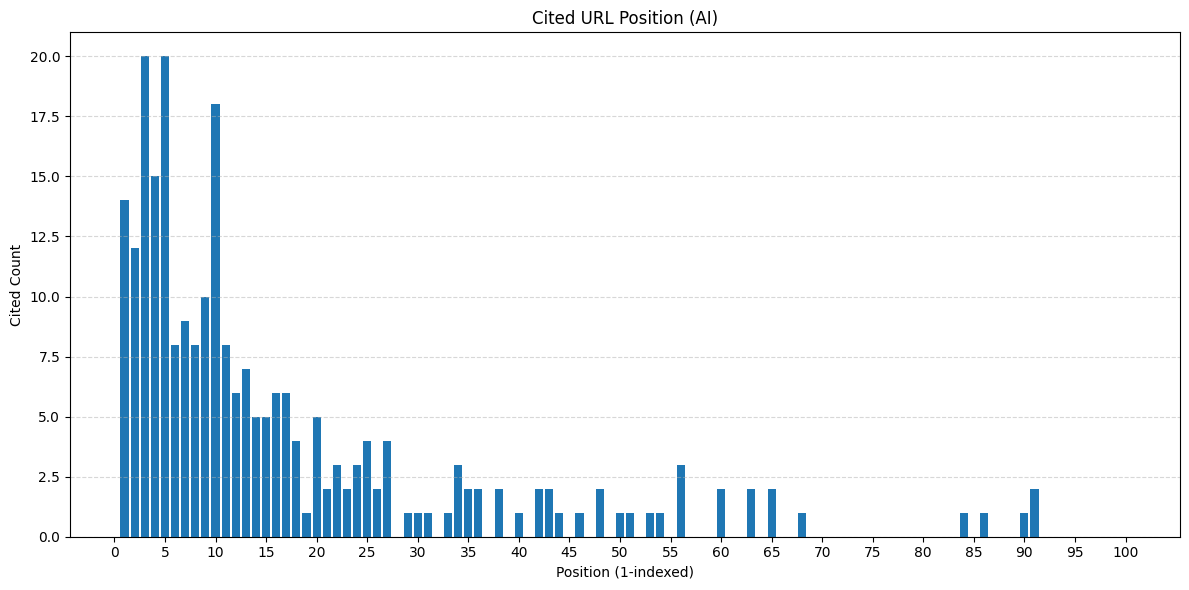

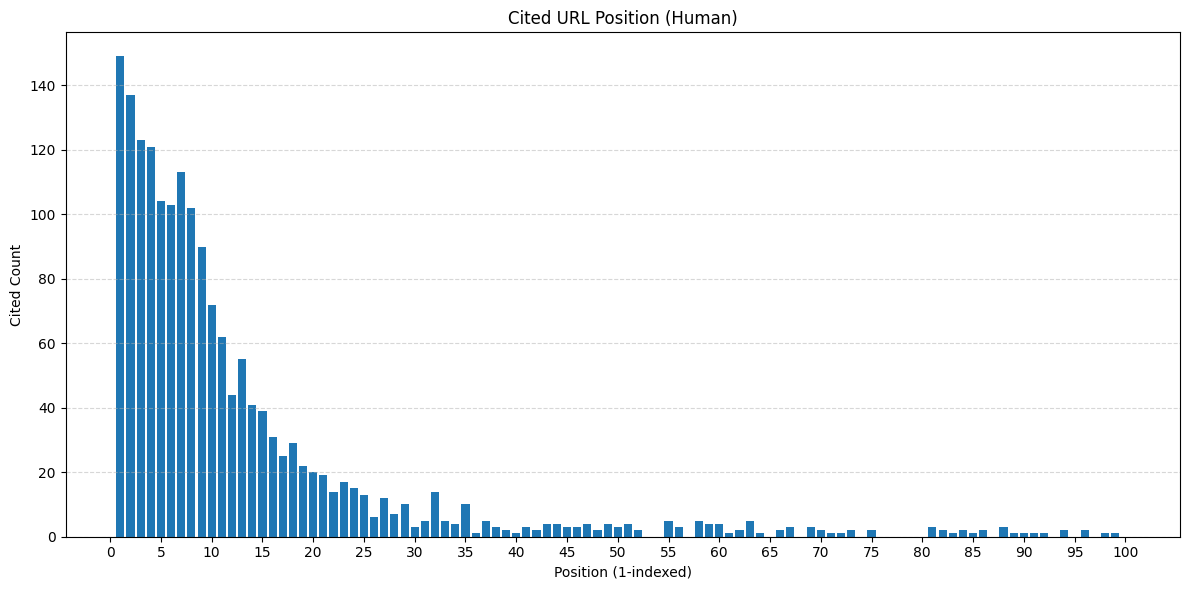

In [296]:
def plot_cited_positions(responses_df, label=None):
    position_counter = Counter()

    for _, row in responses_df.iterrows():
        try:
            refs = set(json.loads(row["references"]))
            organic = json.loads(row["organic_results"])
        except Exception:
            continue

        for i, url in enumerate(organic):
            if url in refs:
                if label is None:
                    position_counter[i + 1] += 1
                else:
                    if label == "AI" and url in set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"]):
                        position_counter[i + 1] += 1
                    elif label == "Human" and url in set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"]):
                        position_counter[i + 1] += 1

    positions = list(range(1, 101))
    counts = [position_counter.get(i, 0) for i in positions]

    plt.figure(figsize=(12, 6))
    plt.bar(positions, counts)
    title = "Cited URL Position"
    if label:
        title += f" ({label})"
    else:
        title += " (All)"
    plt.title(title)
    plt.xlabel("Position (1-indexed)")
    plt.ylabel("Cited Count")
    plt.xticks(range(0, 101, 5))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_cited_positions(responses_df)
plot_cited_positions(responses_df, "AI")
plot_cited_positions(responses_df, "Human")

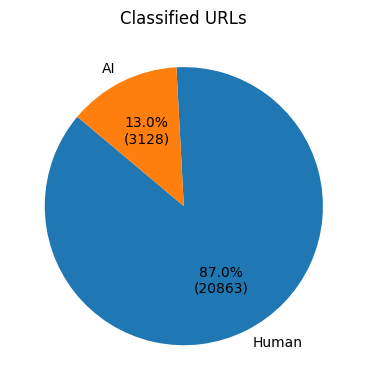

In [287]:
plot_dist_pie(classified_urls_df, 'ai_class', 'Classified URLs')

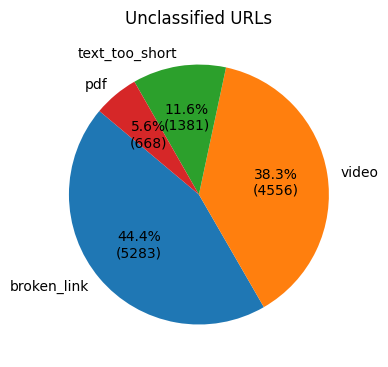

In [288]:
plot_dist_pie(unclassified_urls_df, 'category', 'Unclassified URLs')

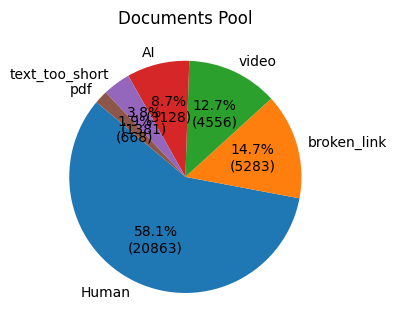

In [289]:
merged_df = pd.concat([
    classified_urls_df[['url']].assign(category=classified_urls_df['ai_class']),
    unclassified_urls_df[['url']].assign(category=unclassified_urls_df['category'])
], ignore_index=True)

plot_dist_pie(merged_df, 'category', 'Documents Pool')

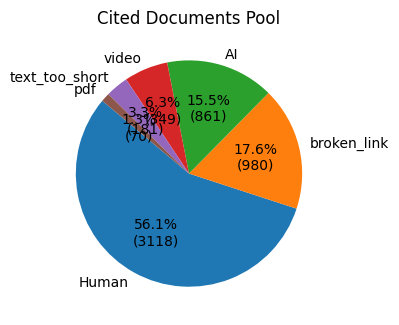

In [290]:
import ast

# Safe temporary copies — no modification to originals
classified_temp = classified_urls_df[["url", "ai_class"]].copy()
classified_temp = classified_temp.rename(columns={"ai_class": "category"})

unclassified_temp = unclassified_urls_df[["url", "category"]].copy()

merged_df = pd.concat([classified_temp, unclassified_temp], ignore_index=True).drop_duplicates(subset="url", keep="last")

# Safely extract normalized cited URLs without modifying responses_df
cited_urls = set()
for refs in responses_df["references"]:
    try:
        parsed = ast.literal_eval(refs) if pd.notnull(refs) else []
        cited_urls.update(url.strip().lower().rstrip('/') for url in parsed)
    except Exception:
        pass

# Normalize merged URLs for matching (but don't touch original DataFrames)
merged_df_temp = merged_df.copy()
merged_df_temp["url"] = merged_df_temp["url"].str.strip().str.lower().str.rstrip('/')

cited_df = merged_df_temp[merged_df_temp["url"].isin(cited_urls)].reset_index(drop=True)

plot_dist_pie(cited_df, 'category', 'Cited Documents Pool')

## By unique document

In [303]:
# Define classified sets
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Define citation sets
cited_urls = set()
cited_from_organic_urls = set()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
        cited_urls.update(refs)
        cited_from_organic_urls.update(refs & organic)
    except Exception:
        continue

# Totals
ai_total = len(ai_urls)
human_total = len(human_urls)

# AI stats
ai_cited = len(cited_urls & ai_urls)
ai_cited_from_organic = len(cited_from_organic_urls & ai_urls)
ai_cited_outside_organic = ai_cited - ai_cited_from_organic

# Human stats
human_cited = len(cited_urls & human_urls)
human_cited_from_organic = len(cited_from_organic_urls & human_urls)
human_cited_outside_organic = human_cited - human_cited_from_organic

# Probabilities (safeguarded)
p_ai_cited = ai_cited / ai_total if ai_total else 0
p_ai_cited_from_organic = ai_cited_from_organic / ai_total if ai_total else 0
p_ai_cited_outside_organic = ai_cited_outside_organic / ai_total if ai_total else 0

p_human_cited = human_cited / human_total if human_total else 0
p_human_cited_from_organic = human_cited_from_organic / human_total if human_total else 0
p_human_cited_outside_organic = human_cited_outside_organic / human_total if human_total else 0

# Output
print("P(cited | AI):", f"{p_ai_cited * 100:.2f}%")
print("P(cited-from-organic | AI):", f"{p_ai_cited_from_organic * 100:.2f}%")
print("P(cited-out-of-organic | AI):", f"{p_ai_cited_outside_organic * 100:.2f}%")
print()
print("P(cited | Human):", f"{p_human_cited * 100:.2f}%")
print("P(cited-from-organic | Human):", f"{p_human_cited_from_organic * 100:.2f}%")
print("P(cited-out-of-organic | Human):", f"{p_human_cited_outside_organic * 100:.2f}%")


P(cited | AI): 27.53%
P(cited-from-organic | AI): 7.93%
P(cited-out-of-organic | AI): 19.60%

P(cited | Human): 14.95%
P(cited-from-organic | Human): 8.34%
P(cited-out-of-organic | Human): 6.61%


## By Google result appearance

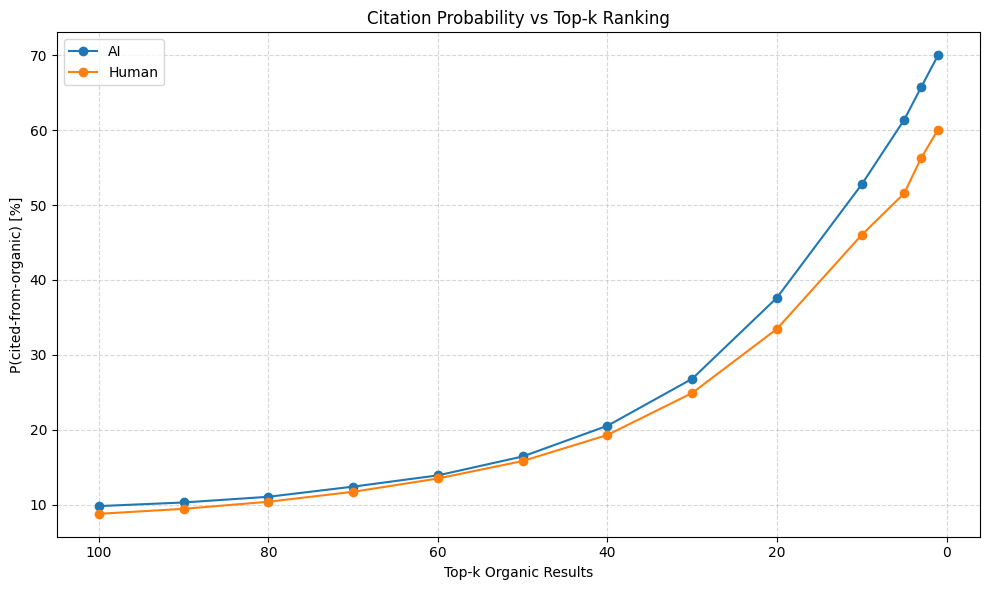

In [307]:
cutoffs = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 5, 3, 1]
p_ai_list = []
p_human_list = []

ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

for k in cutoffs:
    ai_total = ai_cited = human_total = human_cited = 0

    for _, row in responses_df.iterrows():
        try:
            refs = set(json.loads(row["references"]))
            organic = json.loads(row["organic_results"])[:k]
        except Exception:
            continue

        for url in organic:
            if url in ai_urls:
                ai_total += 1
                if url in refs:
                    ai_cited += 1
            elif url in human_urls:
                human_total += 1
                if url in refs:
                    human_cited += 1

    p_ai = ai_cited / ai_total if ai_total else 0
    p_human = human_cited / human_total if human_total else 0

    p_ai_list.append(p_ai * 100)
    p_human_list.append(p_human * 100)

plt.figure(figsize=(10, 6))
plt.plot(cutoffs, p_ai_list, marker='o', label="AI")
plt.plot(cutoffs, p_human_list, marker='o', label="Human")
plt.xlabel("Top-k Organic Results")
plt.ylabel("P(cited-from-organic) [%]")
plt.title("Citation Probability vs Top-k Ranking")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()